In [145]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
import time
import csv
import glob
from diffraction_utils import load_experimental_data
from load_xml_phases import *
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
difr_dir = "../../nn_data/"
os.makedirs(difr_dir, exist_ok=True)

# Автовыбор вычислительного устройства
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('device =', device)

# Вычисляем размер входа для свертки
input_size = 4001
num_phases = 12

xml_name = 'OSO'
model_ver = 'light_3'
wghts_fname = f'weights3_{xml_name}_{model_ver}.pth'
csv_res_fname = f"{xml_name}_{model_ver}.csv"

inp_data = []
out_data = []

PHASES_INFO = []

experiment_folder = 'XY_OSO_midKO'

device = cuda:0


In [3]:
# Создаем словарь для сопоставления имен файлов и целевых значений
target_values = {
    'Бо1125_180121.xy': np.array([0.42, 0.25, 42.72, 44.65, 2.22, 8.05, 0.00, 1.40, 0.28, 0.00, 0.01, 0.00]),
    'Бо2074_200121.xy': np.array([0.50, 0.24, 58.48, 27.85, 2.88, 7.90, 0.05, 1.62, 0.48, 0.00, 0.01, 0.00]),
    'Бо2077_200121.xy': np.array([0.40, 0.93, 67.24, 18.25, 3.63, 7.51, 0.03, 1.60, 0.42, 0.00, 0.00, 0.00]),
    'Бр1026_181220.xy': np.array([2.72, 2.78, 47.84, 28.73, 1.20, 14.57, 0.07, 2.06, 0.03, 0.00, 0.00, 0.00]),
    'Бр1071_241220.xy': np.array([1.22, 0.63, 50.30, 30.39, 1.60, 13.97, 0.06, 1.84, 0.00, 0.00, 0.00, 0.00]),
    'Бр1307_2_181220.xy': np.array([0.68, 1.17, 86.07, 0.94, 3.65, 1.29, 4.55, 0.31, 0.79, 0.05, 0.52, 0.00]),
    'Бр1356_251220.xy': np.array([1.67, 2.21, 78.72, 2.34, 7.51, 3.22, 2.43, 1.09, 0.51, 0.28, 0.02, 0.00]),
    'Бр1425_241220.xy': np.array([0.90, 1.56, 81.95, 1.43, 6.32, 2.76, 3.40, 0.85, 0.68, 0.16, 0.00, 0.00]),
    'Бр1428_241220.xy': np.array([1.07, 2.47, 63.14, 15.82, 0.80, 14.47, 0.66, 1.58, 0.00, 0.00, 0.00, 0.00]),
    'Бр1566_281220.xy': np.array([0.72, 3.95, 70.88, 5.65, 6.65, 9.87, 0.12, 2.14, 0.00, 0.00, 0.01, 0.00]),
    'В506_140121.xy': np.array([2.11, 2.59, 54.29, 21.35, 2.26, 15.51, 0.06, 1.59, 0.24, 0.00, 0.01, 0.00]),
    'В508_140121.xy': np.array([2.12, 3.48, 48.43, 27.17, 1.62, 15.24, 0.05, 1.63, 0.26, 0.00, 0.01, 0.00]),
    'В549_150121.xy': np.array([1.01, 3.74, 78.07, 0.43, 13.37, 0.44, 1.63, 0.24, 0.17, 0.00, 0.89, 0.00]),
    'В574_150121.xy': np.array([0.52, 1.16, 52.24, 24.86, 1.70, 16.05, 0.03, 3.32, 0.11, 0.00, 0.00, 0.00]),
    'В583_180121.xy': np.array([0.45, 1.25, 52.71, 24.86, 2.10, 16.14, 0.06, 2.38, 0.04, 0.00, 0.01, 0.00]),
    'И103_291220.xy': np.array([1.02, 3.74, 53.23, 30.05, 1.25, 5.35, 4.20, 1.05, 0.00, 0.11, 0.00, 0.00]),
    'И128_120121.xy': np.array([1.16, 3.16, 59.49, 23.44, 1.06, 7.46, 2.84, 1.33, 0.00, 0.06, 0.00, 0.00]),
    'И538_110121.xy': np.array([1.42, 0.97, 72.78, 9.48, 2.78, 10.23, 0.42, 1.19, 0.00, 0.72, 0.00, 0.00]),
    'И644_110121.xy': np.array([1.24, 4.00, 73.64, 6.08, 7.94, 4.33, 1.11, 0.93, 0.00, 0.63, 0.00, 0.00]),
    'И743_211220.xy': np.array([0.39, 1.37, 88.97, 0.92, 2.73, 0.32, 4.03, 0.12, 0.42, 0.28, 0.44, 0.00]),
    'И9085_130121.xy': np.array([0.48, 0.14, 42.95, 44.21, 1.04, 10.34, 0.07, 0.71, 0.06, 0.00, 0.00, 0.00]),
    'К173_210121.xy': np.array([0.68, 2.13, 45.16, 36.51, 1.06, 10.94, 0.07, 2.73, 0.29, 0.43, 0.00, 0.00]),
    'К1898_270121.xy': np.array([1.89, 1.83, 55.79, 17.94, 2.05, 13.11, 0.43, 2.62, 0.14, 4.21, 0.00, 0.00]),
    'К2019_270121.xy': np.array([1.30, 3.43, 67.70, 7.81, 2.77, 10.36, 0.05, 2.19, 0.40, 4.00, 0.00, 0.00]),
    'К2022_280121.xy': np.array([1.18, 1.49, 58.94, 15.68, 2.12, 13.57, 0.08, 2.58, 0.46, 3.91, 0.00, 0.00]),
    'К2035_280121.xy': np.array([0.99, 1.88, 57.56, 16.03, 2.68, 12.59, 0.11, 2.36, 0.43, 5.37, 0.00, 0.00]),
    'К2041_280121.xy': np.array([0.95, 2.44, 49.16, 25.80, 1.25, 13.73, 0.07, 2.76, 0.22, 3.62, 0.00, 0.00]),
    'К2042_290121.xy': np.array([0.87, 0.92, 83.39, 0.71, 0.34, 0.11, 6.30, 0.00, 0.24, 4.62, 2.51, 0.00]),
    'С152_161220.xy': np.array([0.26, 1.65, 33.93, 52.38, 0.73, 9.34, 0.27, 0.99, 0.04, 0.38, 0.04, 0.00]),
    'С207_181220.xy': np.array([0.32, 0.61, 42.08, 44.57, 0.83, 9.56, 0.29, 1.31, 0.00, 0.42, 0.00, 0.00]),
    'С294_211220.xy': np.array([0.77, 2.01, 57.04, 26.08, 2.25, 8.96, 0.34, 1.74, 0.00, 0.83, 0.00, 0.00]),
    'С343_221220.xy': np.array([1.84, 1.80, 51.13, 33.75, 1.11, 7.74, 0.75, 1.31, 0.00, 0.56, 0.00, 0.00]),
    'С367_231220.xy': np.array([0.47, 1.94, 56.72, 26.99, 1.58, 9.51, 0.39, 1.60, 0.00, 0.81, 0.00, 0.00]),
    'С455_171220.xy': np.array([0.20, 2.09, 32.42, 53.03, 0.80, 9.33, 0.46, 1.01, 0.00, 0.28, 0.38, 0.00]),
    'С479_231220.xy': np.array([0.73, 1.32, 53.55, 31.52, 1.41, 9.09, 0.29, 1.45, 0.00, 0.63, 0.00, 0.00]),
    'С490_231220.xy': np.array([1.05, 2.49, 55.01, 30.80, 1.07, 4.45, 3.10, 1.48, 0.01, 0.55, 0.00, 0.00]),
    'дБо2058д_240521.xy': np.array([0.00, 0.74, 10.33, 59.61, 2.16, 5.09, 0.13, 21.81, 0.15, 0.00, 0.00, 0.00]),
    'дБо2082д_280521.xy': np.array([0.62, 0.35, 85.91, 0.00, 0.00, 0.00, 3.22, 0.00, 9.42, 0.06, 0.17, 0.00]),
    'дБр1307д_220421.xy': np.array([0.93, 0.36, 85.71, 0.39, 0.35, 0.03, 9.36, 0.00, 0.24, 0.00, 1.22, 1.43]),
    'дБр1552д_020621.xy': np.array([0.89, 0.00, 85.48, 0.25, 0.34, 0.00, 6.05, 0.03, 0.58, 0.00, 0.37, 6.00]),
    'дК1132д_180521.xy': np.array([2.42, 1.47, 75.98, 0.48, 0.61, 0.17, 9.58, 0.06, 4.70, 0.16, 2.08, 2.28]),
    'дК1585д_170521.xy': np.array([0.43, 1.17, 84.69, 0.00, 0.00, 0.00, 9.71, 0.00, 1.83, 1.65, 0.46, 0.00]),
    'дК180д_290421.xy': np.array([0.19, 1.93, 26.94, 42.17, 4.99, 17.44, 0.06, 5.90, 0.00, 0.40, 0.00, 0.00]),
    'дС132д_210421.xy': np.array([0.29, 2.38, 26.13, 41.49, 2.17, 16.56, 0.10, 10.58, 0.27, 0.03, 0.00, 0.00]),
    'дС321д_120521.xy': np.array([0.42, 1.90, 20.31, 38.45, 3.73, 20.36, 0.10, 14.56, 0.00, 0.02, 0.16, 0.00]),
    'дС323д_170521.xy': np.array([0.17, 1.65, 21.48, 30.25, 7.69, 19.54, 0.03, 18.75, 0.14, 0.07, 0.24, 0.00])
}

In [354]:
def predict_experimental_data(model, experimental_data, input_size):
    predictions = []
    total_difference = 0.0
    exp_samples_nb = 0

    diff_by_phases = []
    for i in range(num_phases):
        diff_by_phases.append(0)

    for filename, intensities in experimental_data.items():

        interpolated_intensities = torch.tensor(intensities, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)[:,:,1:]
        model.eval()
        with torch.no_grad():
            predicted_weights = model(interpolated_intensities)

        # Умножаем предсказанные веса на 100
        #predicted_weights *= 100
        
        predictions.append((filename, predicted_weights.squeeze().cpu().numpy()))

        # Сравнение с целевыми значениями, если они есть
        if filename in target_values:
            target = target_values[filename]
            curr_phases = np.square(predicted_weights.squeeze().cpu().numpy() - target*0.01)
            total_difference += curr_phases.sum()
            diff_by_phases += curr_phases  # Аккумулируем разности для каждой фазы
            exp_samples_nb += 1

    if exp_samples_nb > 0:
        total_difference = (total_difference / exp_samples_nb) / num_phases
        diff_by_phases /= exp_samples_nb  # Вычисляем средние значения для каждой фазы
    else:
        total_difference = 0.0
        diff_by_phases = np.zeros(num_phases)

    return total_difference, diff_by_phases, exp_samples_nb

def load_batch_inp_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{input_size}f'))
                if not data:
                    break
                inp = struct.unpack(f'{input_size}f', data)
                inp_data.append(np.array(inp))


def load_batch_out_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{num_phases}f'))
                if not data:
                    break
                out = struct.unpack(f'{num_phases}f', data)
                out_data.append(np.array(out))

In [5]:
# Загрузка данных
inp_files = glob.glob(f"{difr_dir}batch_inp_{xml_name}_{num_phases}ph_p*.bin")
out_files = glob.glob(f"{difr_dir}batch_out_{xml_name}_{num_phases}ph_p*.bin")

print('inp_files',inp_files)

for file in inp_files:
    load_batch_inp_file(file)

for file in out_files:
    load_batch_out_file(file)

print(f"Размер массива out_data: {len(out_data)}\n")

if len(out_data) < 1:
    print("Внимание - нет данных для обучения !")

lim_len = 500000
if len(inp_data) > lim_len:
    inp_data = inp_data[-lim_len:]
if len(out_data) > lim_len:
    out_data = out_data[-lim_len:]

inp_files ['../../nn_data/batch_inp_OSO_12ph_p1_50000.bin', '../../nn_data/batch_inp_OSO_12ph_p3_50000.bin', '../../nn_data/batch_inp_OSO_12ph_p2_50000.bin', '../../nn_data/batch_inp_OSO_12ph_p4_50000.bin']
Размер массива out_data: 200000



In [355]:
out_data[0]

array([4.06117998e-02, 1.57209322e-01, 1.03501059e-01, 9.29933041e-02,
       7.91798532e-02, 8.51616561e-02, 1.94989756e-01, 1.89948182e-08,
       1.64288893e-01, 3.76141361e-06, 6.67450503e-02, 1.53155345e-02])

In [356]:
# Определение класса для датасета
class CandleDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Возвращаем данные без изменения формы
        return torch.tensor(self.inputs[idx], dtype=torch.float32).unsqueeze(0), torch.tensor(self.outputs[idx], dtype=torch.float32)

In [357]:
# Разделение данных на тренировочную и тестовую выборки
indices = list(range(len(inp_data)))
indices = np.array(indices)
np.random.shuffle(indices)
#test_indices = indices[::11]
#train_indices = [i for i in indices if i not in test_indices]
test_indices = indices[:int(0.1*len(indices))]
train_indices = indices[int(0.1*len(indices)):]

train_inputs = [inp_data[i] for i in train_indices]
train_outputs = [out_data[i] for i in train_indices]
test_inputs = [inp_data[i] for i in test_indices]
test_outputs = [out_data[i] for i in test_indices]

train_inputs_np = np.array(train_inputs)[:,1:]
test_inputs_np = np.array(test_inputs)[:,1:]

train_dataset = CandleDataset(train_inputs_np, train_outputs)
test_dataset = CandleDataset(test_inputs_np, test_outputs)

In [358]:
# Загружаем фазы из файлов .phase
sample_info, PHASES_INFO = parse_xml('XRD_Data/OSO_Topas_2022_stidy.tshx')
num_phases = len(PHASES_INFO)

# Загружаем экспериментальные данные
experimental_data = load_experimental_data(experiment_folder)
#print(f'Loaded {len(experimental_data)} experimental diffraction patterns.')

{'Name': 'alpha-Al2O3', 'SpaceGroup': 'R-3cH', 'CellPar': {'a': {'min': 4.755, 'max': 4.77, 'value': 4.7698}, 'b': {'min': None, 'max': None, 'value': 4.7698}, 'c': {'min': 13.0, 'max': 13.05, 'value': 13.0243}, 'alpha': {'min': None, 'max': None, 'value': 90.0}, 'beta': {'min': None, 'max': None, 'value': 90.0}, 'gamma': {'min': None, 'max': None, 'value': 120.0}}, 'ReflectionProfileScherrer': {'CS': {'min': 45.0, 'max': 150.0, 'value': 100.0}, 'Strain': {'min': 0.01, 'max': 0.35, 'value': 0.1}}, 'MDtexDir': [], 'Atoms': [{'Type': 'Al3+', 'X': {'min': None, 'max': None, 'value': 0.0}, 'Y': {'min': None, 'max': None, 'value': 0.0}, 'Z': {'min': None, 'max': None, 'value': 0.35231}, 'Occ': {'min': None, 'max': None, 'value': 1.0}}, {'Type': 'O2-', 'X': {'min': None, 'max': None, 'value': 0.6936}, 'Y': {'min': None, 'max': None, 'value': 0.0}, 'Z': {'min': None, 'max': None, 'value': 0.25}, 'Occ': {'min': None, 'max': None, 'value': 1.0}}], 'RIR': -1} 

{'Name': 'gamma-Al2O3', 'SpaceGrou

In [340]:
#small
class DiffractionNet(nn.Module):
    def __init__(self, input_size, num_phases):
        super().__init__()
        
        # Сверточные слои: уменьшены более агрессивно (в ~2.5 раза)
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3),  # Было 64
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),  # Было 128
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1), # Было 256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        reduced_size = input_size // 8
        
        # Трансформер: один слой + уменьшенная размерность
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=500, nhead=10, dim_feedforward=256, dropout=0.1, batch_first=True), # d_model и dim_feedforward уменьшены
            num_layers=1  # Один слой
        )
        
        # Полносвязные слои: значительно уменьшены
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * reduced_size, 256),  # Было 1024
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_phases)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        #x = x.permute(0, 2, 1)  # Критичный шаг сохранён
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc_layers(x)
        x = F.softmax(x, dim=1)
        return x

In [277]:
#big
class DiffractionNet(nn.Module):
    def __init__(self, input_size, num_phases):
        super(DiffractionNet, self).__init__()
        
        # Сверточные слои для извлечения локальных признаков
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Размер выхода после сверточных слоев
        reduced_size = input_size // 8  # Поскольку мы делаем три пулинга с шагом 2
        
        # Трансформер для глобального понимания
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=256, nhead=8, dim_feedforward=512, dropout=0.1, batch_first=True),
            num_layers=2
        )
        
        # Полносвязные слои для получения итогового предсказания
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * reduced_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024, num_phases)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.permute(0, 2, 1)  # Изменяем форму для трансформера (batch_size, sequence_length, features)
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)  # Флэттенинг с использованием reshape
        x = self.fc_layers(x)
        x = F.softmax(x, dim=1)  # Нормированные доли
        return x

In [35]:
#FFN
class DiffractionNet(nn.Module):
    def __init__(self, input_size, num_phases):
        super().__init__()        
        
        # Полносвязные слои: значительно уменьшены
        self.fc_layers = nn.Sequential(
            nn.Linear(4001, 2048),  # Было 1024
            #nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(2048,1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024,256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_phases)
        )
    
    def forward(self, x):
        #x = self.conv_layers(x)
        #x = x.permute(0, 2, 1)  # Критичный шаг сохранён
        #x = self.transformer(x)
        #x = x.reshape(x.size(0), -1)
        x = x.view(-1,4001)
        #print(x.shape)
        x = self.fc_layers(x)
        #print(x.shape)
        x = F.softmax(x, dim=1)
        #print(x.shape)
        return x

In [256]:
#conv_ff
class DiffractionNet(nn.Module):
    def __init__(self, input_size, num_phases):
        super().__init__()
        self.fc_layers = nn.Sequential(            
            nn.Linear(4001, 256),
            nn.ReLU(),
            nn.Linear(256, num_phases)
        )
    
    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        x = self.fc_layers(x)
        x = F.softmax(x, dim=1)
        return x

In [494]:
#ff_40_100
class DiffractionNet(nn.Module):
    def __init__(self, input_size, num_phases):
        super().__init__()
        self.fc_layers = nn.Sequential(            
            nn.Linear(4040, num_phases)
        )
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=40, nhead=8, dim_feedforward=128, dropout=0.1, batch_first=True),
            num_layers=1
        )
        self.positional_embedding=nn.Parameter(torch.randn(1, 1, 40))
    
    def forward(self, x):
        x = x.view(-1,40,100).permute(0, 2, 1)
        positional_embeddings = self.positional_embedding.expand(x.shape[0], 1, 40)
        x = torch.cat((positional_embeddings, x), dim=1)
        x = self.transformer(x)
        x = x.view(-1,4040)
        x = self.fc_layers(x)
        x = F.softmax(x, dim=1)
        return x

In [496]:
# Создание экземпляра модели
model = DiffractionNet(input_size, num_phases).to(device)
print(model)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

DiffractionNet(
  (fc_layers): Sequential(
    (0): Linear(in_features=4040, out_features=12, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=40, out_features=40, bias=True)
        )
        (linear1): Linear(in_features=40, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=40, bias=True)
        (norm1): LayerNorm((40,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((40,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)
65660


In [497]:
print('Start training')
learn_rate = 1E-4
# Определяем критерий потерь и оптимизатор
criterion = nn.MSELoss(reduction='none')  # Используем reduction='none' для получения ошибки для каждого элемента в батче
optimizer = optim.AdamW(model.parameters(), lr=learn_rate, weight_decay=learn_rate*0.1)
def find_index_of_max(float_array):
    max_index = np.argmax(float_array)
    return max_index

# Определяем категории для балансировки данных
def get_category(out):
    min_val = np.min(out)
    max_val = np.max(out)
    delta = min_val / max_val if max_val > 0 else 0.0
    if delta < 0.001:
        return 0
    elif 0.001 <= delta < 0.01:
        return 1
    elif 0.01 <= delta < 0.1:
        return 2
    else:
        return 3
# Определяем метки классов для балансировки
train_labels = np.array([find_index_of_max(out) for out in train_outputs])
print('train_labels',train_labels)
class_counts = np.bincount(train_labels.astype(np.int64))
print(f'Category class_counts = {class_counts}')
# Добавляем сглаживание для предотвращения деления на ноль
#smoothing_factor = 1e-3
#class_weights = 1. / (class_counts + smoothing_factor)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
# Загрузка данных
train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

n_train_iter = len(train_dataloader)
n_test_iter = len(test_dataloader)
print(f'train_iter: {n_train_iter}, test_iter: {n_test_iter}')
# Инициализация списков для хранения значений потерь
train_losses = []
test_losses = []

# Инициализация списков для хранения значений потерь для каждого параметра
train_param_losses = [[] for _ in range(num_phases)]
test_param_losses = [[] for _ in range(num_phases)]

# Создание и запись заголовков в CSV-файл
with open(csv_res_fname, mode='w', newline='') as file:
    writer = csv.writer(file, delimiter=';')
    header = ['Time', 'Epoch', 'Train Loss', 'Test Loss', 'Exp_Diff'] + \
             [f'Train_{i + 1}' for i in range(num_phases)] + \
             [f'Test_{i + 1}' for i in range(num_phases)] + \
             [f'Exp_{i + 1}' for i in range(num_phases)]
    writer.writerow(header)

num_epochs = 300

total_exp_diff = 0.0
ph_exp_diff = []

pre_fitness = 1E6

train_all_losses = []
test_all_losses = []
train_batch_losses = []
test_batch_losses = []
experimental_losses = []

scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=30)

Start training
train_labels [3 6 4 ... 0 4 4]
Category class_counts = [15019 14892 14981 14978 14926 14793 14891 15077 15094 15085 15256 15008]
train_iter: 1407, test_iter: 157


In [502]:
start_time = time.time()  # Запоминаем время начала обучения

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    running_train_param_losses = [0.0 for _ in range(num_phases)]
    iters = 0
    #train_batch_losses = []
    for inputs, outputs in train_dataloader:
        inputs, outputs = inputs.to(device), outputs.to(device)
        optimizer.zero_grad()
        predictions = model(inputs)        
        loss = criterion(predictions, outputs)
        loss.mean().backward()  # Средняя ошибка по всем элементам в батче
        # Градиенты масштабируются, если их общая норма > 1.0
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        #running_train_loss += loss.mean().item()
        #for i in range(num_phases):
        #    running_train_param_losses[i] += loss[:, i].mean().item()
        iters += 1
        #train_batch_losses.append(loss.mean(axis=1).cpu().detach().numpy())

        if iters % 500 == 0:
            print(f"Iteration {iters}")
    #train_all_losses.append(np.array(train_batch_losses[:-1]))

    #train_loss = running_train_loss / n_train_iter
    #train_losses.append(train_loss)
    #for i in range(num_phases):
    #    train_param_losses[i].append(running_train_param_losses[i] / n_train_iter)

    if n_test_iter > 0:
        
        train_batch_losses = []
        model.eval()
        running_train_param_losses = [0.0 for _ in range(num_phases)]
        with torch.no_grad():
            for inputs, outputs in train_dataloader:
                inputs, outputs = inputs.to(device), outputs.to(device)
                predictions = model(inputs)
                loss = criterion(predictions, outputs)
                running_train_loss += loss.mean().item()
                for i in range(num_phases):
                    running_train_param_losses[i] += loss[:, i].mean().item()
                train_batch_losses.append(loss.mean(axis=1).cpu().detach().numpy())
        train_loss = running_train_loss / n_train_iter
        train_losses.append(train_loss)
        for i in range(num_phases):
            train_param_losses[i].append(running_train_param_losses[i] / n_train_iter)
        train_all_losses.append(np.array(train_batch_losses[:-1]))
        

        
        test_batch_losses = []
        model.eval()
        running_test_loss = 0.0
        running_test_param_losses = [0.0 for _ in range(num_phases)]
        with torch.no_grad():
            for inputs, outputs in test_dataloader:
                inputs, outputs = inputs.to(device), outputs.to(device)
                predictions = model(inputs)
                loss = criterion(predictions, outputs)
                running_test_loss += loss.mean().item()
                for i in range(num_phases):
                    running_test_param_losses[i] += loss[:, i].mean().item()
                test_batch_losses.append(loss.mean(axis=1).cpu().detach().numpy())
        test_loss = running_test_loss / n_test_iter
        test_losses.append(test_loss)
        for i in range(num_phases):
            test_param_losses[i].append(running_test_param_losses[i] / n_test_iter)
        test_all_losses.append(np.array(test_batch_losses[:-1]))

        

        total_exp_diff, ph_exp_diff, exp_samples_nb = predict_experimental_data(model, experimental_data, input_size)
        experimental_losses.append(total_exp_diff)

        # Вывод средней разницы, если были найдены соответствия
        if exp_samples_nb > 0:
            if total_exp_diff < pre_fitness:
                #torch.save(model.state_dict(), wghts_fname)
                #print(f'*** Weights are saved to {wghts_fname} after epoch {epoch + 1}')
                pre_fitness = total_exp_diff
            print(f' >>> Средняя разница между предсказанными и OSO: {total_exp_diff:.5g}')
        else:
            total_exp_diff = 0.0
            print('Нет соответствий для подсчета разницы.')

    else:
        test_loss = 0.0
        test_losses.append(test_loss)

    #print(f'Epoch [{epoch + 1}/{num_epochs}], learn_rate: {scheduler.get_last_lr()}, Train Loss: {100 * np.sqrt(train_loss):.5f}, Test Loss: {100 * np.sqrt(test_loss):.5f}')
    print(f'Epoch [{epoch + 1}/{num_epochs}], learn_rate: {scheduler.get_last_lr()}, Train Loss: {1 * (train_loss):.5g}, Test Loss: {1 * (test_loss):.5g}')

    # Вывод ошибок для каждого параметра
    for i in range(num_phases):
        print(f'Фаза {i + 1}: Train: {1 * (train_param_losses[i][-1]):.5g}, Test: {1 * (test_param_losses[i][-1]):.5g}')

    # Форматирование прошедшего времени в "hh:mm:ss"
    elapsed_time = time.time() - start_time  # Вычисляем прошедшее время
    hours, rem = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(rem, 60)
    formatted_time = f"{int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}"

    # Запись данных в CSV-файл
    with open(csv_res_fname, mode='a', newline='') as file:
        writer = csv.writer(file, delimiter=';')
        row = [formatted_time, epoch + 1, 100 * np.sqrt(train_loss), 100 * np.sqrt(test_loss), total_exp_diff] + \
              [100 * np.sqrt(train_param_losses[i][-1]) for i in range(num_phases)] + \
              [100 * np.sqrt(test_param_losses[i][-1]) for i in range(num_phases)] + \
              ph_exp_diff.tolist()
        writer.writerow(row)

    print(f'Прошло времени: {formatted_time}\n')

    scheduler.step()

Iteration 500
Iteration 1000
 >>> Средняя разница между предсказанными и OSO: 5.2333e-05
Epoch [1/300], learn_rate: [0.0001], Train Loss: 1.7054e-05, Test Loss: 1.7141e-05
Фаза 1: Train: 1.1887e-05, Test: 1.2213e-05
Фаза 2: Train: 3.1455e-05, Test: 3.0323e-05
Фаза 3: Train: 1.8117e-05, Test: 1.8052e-05
Фаза 4: Train: 3.6676e-05, Test: 3.6441e-05
Фаза 5: Train: 1.3015e-05, Test: 1.3701e-05
Фаза 6: Train: 1.2878e-05, Test: 1.3448e-05
Фаза 7: Train: 1.0837e-05, Test: 1.0981e-05
Фаза 8: Train: 1.9757e-05, Test: 1.9534e-05
Фаза 9: Train: 1.6374e-05, Test: 1.6533e-05
Фаза 10: Train: 1.2047e-05, Test: 1.2253e-05
Фаза 11: Train: 1.1368e-05, Test: 1.1418e-05
Фаза 12: Train: 1.0238e-05, Test: 1.0801e-05
Прошло времени: 00:00:07

Iteration 500
Iteration 1000
 >>> Средняя разница между предсказанными и OSO: 5.4828e-05
Epoch [2/300], learn_rate: [9.972609476841367e-05], Train Loss: 1.4011e-05, Test Loss: 1.4292e-05
Фаза 1: Train: 1.252e-05, Test: 1.2652e-05
Фаза 2: Train: 1.7058e-05, Test: 1.6836e-

In [499]:
np_train_all_losses = np.array(train_all_losses)
np_test_all_losses = np.array(test_all_losses)
print(np_train_all_losses.shape)
print(np_test_all_losses.shape)
len_train = np_train_all_losses.shape[1]*np_train_all_losses.shape[2]
print(len_train)
len_test = np_test_all_losses.shape[1]*np_test_all_losses.shape[2]
print(len_test)
np_train_all_losses = np_train_all_losses.reshape(np_train_all_losses.shape[0],len_train)
np_test_all_losses = np_test_all_losses.reshape(np_train_all_losses.shape[0],len_test)
inter1 = 299
print(np.mean(np_train_all_losses[inter1]))
print(np.std(np_train_all_losses[inter1]))
print(np.median(np_train_all_losses[inter1]))
print(np.mean(np_test_all_losses[inter1]))
print(np.std(np_test_all_losses[inter1]))
print(np.median(np_test_all_losses[inter1]))
x_scaled = np.arange(len_test)*len_train/len_test
print(x_scaled)

(300, 1406, 128)
(300, 156, 128)
179968
19968
1.1117322e-05
8.9302575e-06
8.745644e-06
1.1414531e-05
9.441724e-06
8.913791e-06
[0.00000000e+00 9.01282051e+00 1.80256410e+01 ... 1.79940962e+05
 1.79949974e+05 1.79958987e+05]


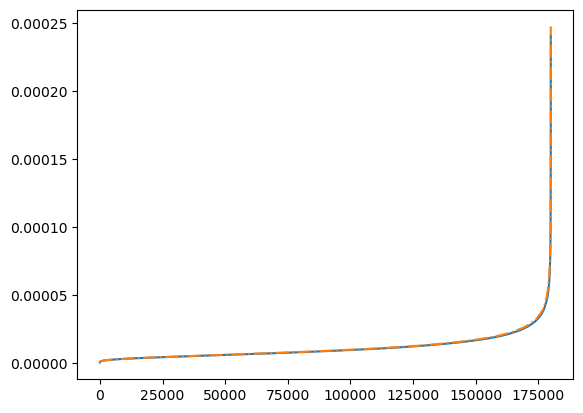

In [500]:
plt.plot(np.sort(np_train_all_losses[inter1]))
plt.plot(x_scaled,np.sort(np_test_all_losses[inter1]),linestyle='-.')
plt.show()

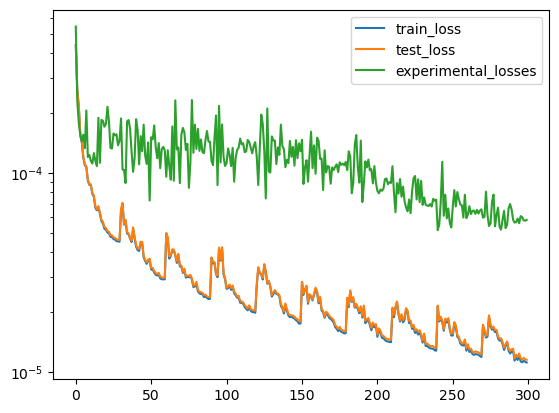

In [501]:
plt.plot(train_losses,label='train_loss')
plt.plot(test_losses,label='test_loss')
plt.plot(experimental_losses,label='experimental_losses')
plt.legend()
plt.yscale('log')
plt.show()